### Import Libraries

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Load the Dataset

In [24]:
df = pd.read_csv(r"C:\Users\Shrabani P\IronHack\Week6_Day2\Project_3\Project3_amazon-review-insights\data\processed\amazon_reviews_cleaned_v2.csv")

In [25]:
df.head()

,id,name,brand,categories,asins,reviews.rating,reviews.title,reviews.text,reviews.username,reviews.date,review_length
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Kindle,This product so far has not disappointed. My c...,Adapter,2017-01-13 00:00:00+00:00,27
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,very fast,great for beginner or experienced person. Boug...,truman,2017-01-13 00:00:00+00:00,14
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,DaveZ,2017-01-13 00:00:00+00:00,26
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love...,Shacks,2017-01-13 00:00:00+00:00,117
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,explore42,2017-01-12 00:00:00+00:00,117


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59741 entries, 0 to 59740
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                59741 non-null  object 
 1   name              59741 non-null  object 
 2   brand             59741 non-null  object 
 3   categories        59741 non-null  object 
 4   asins             59741 non-null  object 
 5   reviews.rating    59741 non-null  float64
 6   reviews.title     59741 non-null  object 
 7   reviews.text      59741 non-null  object 
 8   reviews.username  59741 non-null  object 
 9   reviews.date      59600 non-null  object 
 10  review_length     59741 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 5.0+ MB


In [27]:
df.isnull().sum()

id                    0
name                  0
brand                 0
categories            0
asins                 0
reviews.rating        0
reviews.title         0
reviews.text          0
reviews.username      0
reviews.date        141
review_length         0
dtype: int64

In [28]:
df.duplicated().sum()

0

In [29]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,59741,88,AVphgVaX1cnluZ0-DR74,10966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,59741,119,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",10962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,59741,6,Amazon,42685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories,59741,101,"Fire Tablets,Tablets,Computers & Tablets,All T...",10966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asins,59741,91,B018Y229OU,10966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.rating,59741.0,NaN,NaN,NaN,4.548903,0.837044,1.0,4.0,5.0,5.0,5.0
reviews.title,59741,25700,Five Stars,3332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.text,59741,46874,"A great Christmas gift, the kids love the gift...",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.username,59741,36851,ByAmazon Customer,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.date,59600,1329,2017-01-23 00:00:00+00:00,1089,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
df.columns

Index(['id', 'name', 'brand', 'categories', 'asins', 'reviews.rating',
       'reviews.title', 'reviews.text', 'reviews.username', 'reviews.date',
       'review_length'],
      dtype='object')

### Explore the Existing Categories

In [31]:
df["categories"].head()

0    Electronics,iPad & Tablets,All Tablets,Fire Ta...
1    Electronics,iPad & Tablets,All Tablets,Fire Ta...
2    Electronics,iPad & Tablets,All Tablets,Fire Ta...
3    Electronics,iPad & Tablets,All Tablets,Fire Ta...
4    Electronics,iPad & Tablets,All Tablets,Fire Ta...
Name: categories, dtype: object

In [32]:
df["categories"].nunique()

101

In [33]:
df["categories"].value_counts().head(20)

categories
Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               10966
AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal

### Decide Which Text to Cluster
Instead of clustering only reviews, combine product information.

A good feature is:

In [34]:
df["cluster_text"] = (
    df["name"].fillna("") + " " +
    df["brand"].fillna("") + " " +
    df["categories"].fillna("") + " " +
    df["reviews.text"].fillna("")
)

### TF-IDF Vectorization

In [35]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = tfidf.fit_transform(df["cluster_text"])

### Dataset Analysis for Product Categories

The dataset contains information about Amazon products, including product names, brands, categories, and customer reviews. The original categories column contains many detailed and overlapping product categories, making it difficult to analyze products at a higher level.

To better understand the dataset, the following analyses were performed:

Examined the unique values and frequency distribution of the categories column.
Reviewed the most common product brands.
Combined product name, brand, category, and review text into a single text feature.
Converted the combined text into TF-IDF vectors to capture important terms while reducing the influence of common words.
Applied K-Means clustering to group similar products based on textual similarity rather than relying solely on predefined category labels.

### Find the Best Number of Clusters

In [36]:
scores = []

for k in range(4,7):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    scores.append(score)

    print(k, score)

4 0.280066201777473
5 0.2208426733581542
6 0.23099124870015444


### Within-Cluster Sum of Squares

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

### Plot the Elbow Curve

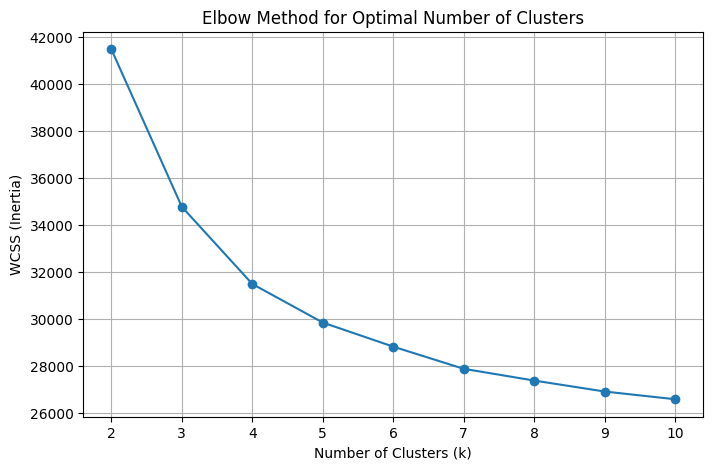

In [38]:
plt.figure(figsize=(8,5))

plt.plot(K, wcss, marker='o')

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(K)
plt.grid(True)

plt.show()

### Train the Final Model

In [39]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X)

### Explore Each Cluster

In [40]:
df.groupby("Cluster")["name"].head(20)

0        All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
1        All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
2        All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
3        All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
4        All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
                               ...                        
34639    AmazonBasics AAA Performance Alkaline Batterie...
34640    AmazonBasics AAA Performance Alkaline Batterie...
34641    AmazonBasics AAA Performance Alkaline Batterie...
34642    AmazonBasics AAA Performance Alkaline Batterie...
34643    AmazonBasics AAA Performance Alkaline Batterie...
Name: name, Length: 80, dtype: object

In [41]:
df.groupby("Cluster")["brand"].value_counts().head(10)

Cluster  brand                       
0        Amazon                           8097
         Amazon Echo                       636
1        AmazonBasics                    10996
2        Amazon                          34575
         Amazon Fire                       256
         AmazonBasics                      102
         Amazon Digital Services Inc.       10
3        Amazon Fire Tv                   5056
         Amazon                             13
Name: count, dtype: int64

In [42]:
df.groupby("Cluster")["categories"].value_counts().head(10)

Cluster  categories                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
0        Stereos,Remote Controls,Amazon Echo,Audio D

### Find Keywords

In [44]:
terms = tfidf.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(4):

    print(f"\nCluster {i}")

    keywords = [terms[ind] for ind in order_centroids[i,:15]]

    print(keywords)


Cluster 0
['home', 'smart', 'audio', 'echo', 'speakers', 'amazon', 'automation', 'voice', 'assistants', 'hubs', 'security', 'wireless', 'clearance', 'accessories', 'devices']

Cluster 1
['batteries', 'health', 'household', 'amazonbasics', 'care', 'camera', 'aaa', 'aa', 'alkaline', 'performance', 'count', 'camcorder', 'baby', 'beauty', 'supplies']

Cluster 2
['tablets', 'tablet', 'computers', 'amazon', 'electronics', 'hd', 'readers', 'display', 'gb', 'wi', 'fi', 'offers', 'special', 'ipad', 'includes']

Cluster 3
['streaming', 'tv', 'college', 'theater', 'home', 'players', 'media', 'tvs', 'shop', 'devices', 'ways', 'unknown', 'electronics', 'family', 'video']


### Assign Meaningful Names

In [45]:
cluster_names = {
    0: "Smart Home & Alexa Devices",
    1: "Batteries & Household Essentials",
    2: "Tablets & eReaders",
    3: "Electronics & Streaming Devices",
 
}

df["Meta_Category"] = df["Cluster"].map(cluster_names)

### After applying clustering, you should interpret each cluster by examining its representative keywords, product names, brands, and categories. Based on the keywords, here is a suitable analysis for your notebook.

Cluster 0: Smart Home & Alexa Devices

This cluster contains products related to Amazon's smart home ecosystem. The dominant keywords include echo, smart, audio, speakers, voice, assistants, and hubs, indicating devices such as Echo speakers and Alexa-enabled smart home accessories. These products are primarily designed for voice control, home automation, and wireless connectivity.

Cluster 1: Batteries & Household Essentials

This cluster groups together batteries and everyday household products. Keywords such as batteries, amazonbasics, AA, AAA, alkaline, health, and household suggest that it contains disposable batteries, personal care items, and household supplies. The presence of AmazonBasics products indicates a focus on essential consumer goods.

Cluster 2: Tablets & eReaders

This cluster is characterized by keywords including tablets, tablet, readers, HD, display, electronics, and Fire. These terms indicate Amazon's portable computing devices, such as Fire tablets and Kindle eReaders. The products in this cluster emphasize digital reading, entertainment, and portable computing.

Cluster 3: Electronics & Streaming Devices

This cluster focuses on entertainment electronics. Keywords such as streaming, TV, media, theater, video, and players indicate streaming devices like Amazon Fire TV, media players, and home entertainment products. These devices are designed for video streaming and multimedia consumption.

### Visualize

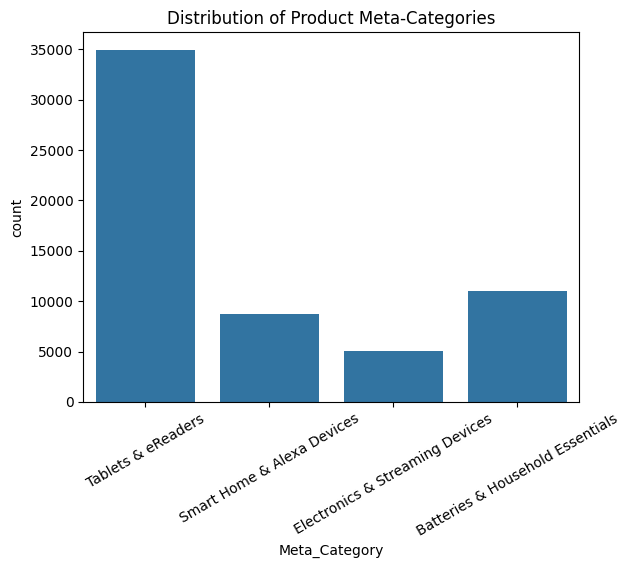

In [46]:
sns.countplot(
    data=df,
    x="Meta_Category"
)

plt.xticks(rotation=30)

plt.title("Distribution of Product Meta-Categories")

plt.show()

### Why do we use PCA?

Your TF-IDF matrix X has thousands of features (one feature for each important word). Humans cannot visualize data with thousands of dimensions, so we reduce it to 2 dimensions using Principal Component Analysis (PCA).

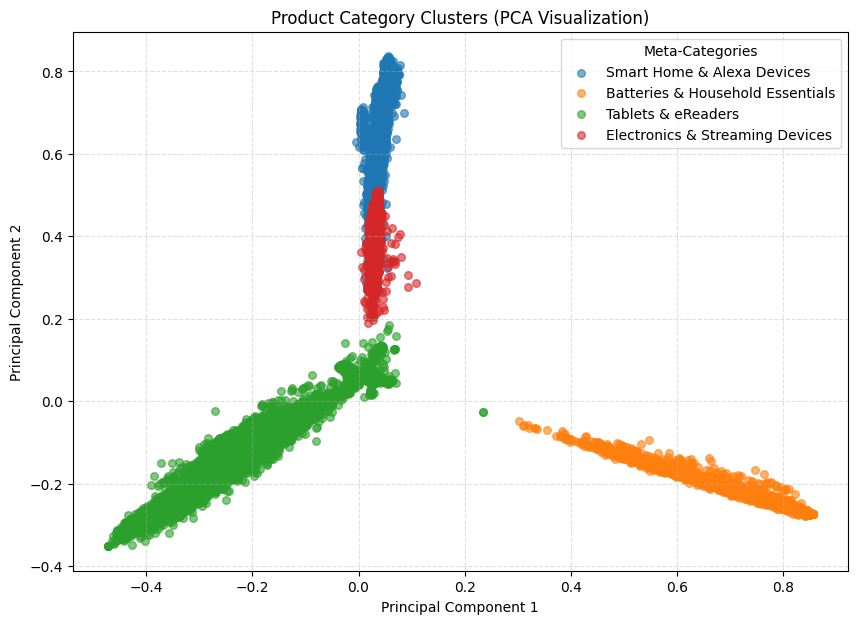

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce TF-IDF features to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 7))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for cluster in sorted(df["Cluster"].unique()):
    plt.scatter(
        X_pca[df["Cluster"] == cluster, 0],
        X_pca[df["Cluster"] == cluster, 1],
        label=cluster_names[cluster],
        color=colors[cluster],
        alpha=0.6,
        s=30
    )

plt.title("Product Category Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Meta-Categories")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### The original TF-IDF representation contained thousands of features, making it impossible to visualize directly. Principal Component Analysis (PCA) was applied to reduce the data to two dimensions. The first principal component (PCA 1) captures the greatest amount of variance in the data, while the second principal component (PCA 2) captures the second greatest amount of variance. These two components provide a two-dimensional representation that allows the discovered clusters to be visualized while preserving as much of the original information as possible.